In [1]:
#https://www.kaggle.com/code/hasnainaliasghar941/pca-test -> main code
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/digit-recognizer/sample_submission.csv
/kaggle/input/competitions/digit-recognizer/train.csv
/kaggle/input/competitions/digit-recognizer/test.csv


In [2]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

import plotly.express as px

In [3]:
df = pd.read_csv("/kaggle/input/competitions/digit-recognizer/train.csv")

In [4]:
df.sample(5)

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
10966,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
11075,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7630,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
37110,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
28205,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


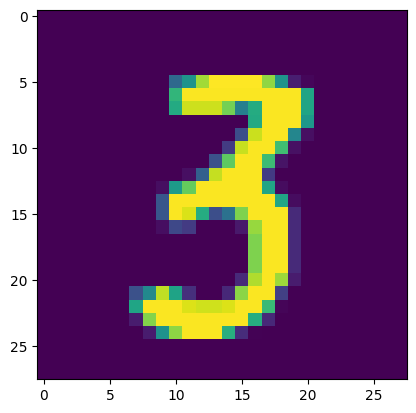

In [5]:
plt.imshow(df.iloc[21703,1:].values.reshape(28,28))

In [6]:
X = df.drop(columns = "label")
y =  df["label"]

In [7]:
X_train,X_test,y_train,y_test = train_test_split(X,y, random_state = 42, test_size = 0.2)
X_train.shape

(33600, 784)

# Without PCA

In [8]:
knn = KNeighborsClassifier()

In [9]:
knn.fit(X_train,y_train)

KNeighborsClassifier()

In [10]:
y_pred = knn.predict(X_test)

In [11]:
accuracy_score(y_test,y_pred)

0.9648809523809524

# With PCA

In [12]:
#Finding maximum Accurracy among 100
maxi = 0
ind = 0

for i in range(1,101):
    pca = PCA(n_components= i)
    X_train_trf = pca.fit_transform(X_train)
    X_test_trf = pca.transform(X_test)
    knn = KNeighborsClassifier()
    knn.fit(X_train_trf,y_train)
    y_pred = knn.predict(X_test_trf)


    acc = accuracy_score(y_test,y_pred)
    
    if acc > maxi:
        maxi = acc
        ind = i
        
    print("Accurate:",i,".", accuracy_score(y_test,y_pred))

print(f"\n{ind} has maximum of {maxi}")

Accurate: 1 . 0.2730952380952381
Accurate: 2 . 0.42214285714285715
Accurate: 3 . 0.48488095238095236
Accurate: 4 . 0.6194047619047619
Accurate: 5 . 0.7297619047619047
Accurate: 6 . 0.8188095238095238
Accurate: 7 . 0.866904761904762
Accurate: 8 . 0.8938095238095238
Accurate: 9 . 0.9075
Accurate: 10 . 0.9247619047619048
Accurate: 11 . 0.9315476190476191
Accurate: 12 . 0.9421428571428572
Accurate: 13 . 0.9492857142857143
Accurate: 14 . 0.954047619047619
Accurate: 15 . 0.9544047619047619
Accurate: 16 . 0.9583333333333334
Accurate: 17 . 0.9616666666666667
Accurate: 18 . 0.9626190476190476
Accurate: 19 . 0.9644047619047619
Accurate: 20 . 0.9654761904761905
Accurate: 21 . 0.9665476190476191
Accurate: 22 . 0.9683333333333334
Accurate: 23 . 0.9694047619047619
Accurate: 24 . 0.9703571428571428
Accurate: 25 . 0.9704761904761905
Accurate: 26 . 0.9709523809523809
Accurate: 27 . 0.9708333333333333
Accurate: 28 . 0.9705952380952381
Accurate: 29 . 0.9714285714285714
Accurate: 30 . 0.9716666666666667
A

In [13]:
scaler = StandardScaler()

In [14]:
pca = PCA(n_components=ind)

X_train_trf = pca.fit_transform(X_train)
X_test_trf = pca.transform(X_test)
X_train_trf.shape

(33600, 48)

In [15]:
knn = KNeighborsClassifier()
knn.fit(X_train_trf,y_train)
y_pred = knn.predict(X_test_trf)

In [16]:
accuracy_score(y_test,y_pred)

0.9732142857142857

## 3D Visualization

In [17]:
pca = PCA(n_components=2)
X_train_trf = pca.fit_transform(X_train)
X_test_trf = pca.transform(X_test)
X_train_trf


array([[-226.60523462, -305.89437099],
       [  38.33583717,  461.09152047],
       [-305.49225463,  351.67141678],
       ...,
       [ -28.00133402, -596.06287179],
       [ 233.97011308,  -18.64779077],
       [1096.50373629,  254.72333173]])

In [18]:
y_train_trf = y_train.astype(str)
fig = px.scatter(
    x = X_train_trf[:,0],
    y = X_train_trf[:,1],
    color=y_train_trf,
    color_discrete_sequence = px.colors.qualitative.G10
    
)

fig.show()

In [19]:
pca = PCA(n_components=3)
X_train_trf = pca.fit_transform(X_train)
X_test_trf = pca.transform(X_test)
X_train_trf


array([[-226.60523462, -305.89437099, -417.17563833],
       [  38.33583717,  461.09152047, -100.40840682],
       [-305.49225463,  351.67141678,  961.3475787 ],
       ...,
       [ -28.00133402, -596.06287179, -606.25130926],
       [ 233.97011308,  -18.64779077,  148.27481803],
       [1096.50373629,  254.72333173,  560.33354832]])

In [22]:
y_train_trf = y_train.astype(str)
fig = px.scatter_3d(
    x = X_train_trf[:,0],
    y = X_train_trf[:,1],
    z=X_train_trf[:, 2],
    color=y_train_trf,
    color_discrete_sequence = px.colors.qualitative.G10
    
)

fig.show()

In [24]:
#Eigen Values
pca.explained_variance_

array([335506.57620544, 244807.10511442, 212051.0345165 ])

In [25]:
#Eigen Vectors
pca.components_.shape

(3, 784)

In [26]:
pca.explained_variance_ratio_

array([0.09770722, 0.07129345, 0.06175413])

In [27]:
pca = PCA(n_components=None)
X_train_trf = pca.fit_transform(X_train)
X_test_trf = pca.transform(X_test)
X_train_trf


array([[-2.26605235e+02, -3.05894371e+02, -4.17175638e+02, ...,
         8.55654044e-11,  3.53858799e-10,  6.69141677e-11],
       [ 3.83358372e+01,  4.61091520e+02, -1.00408407e+02, ...,
         5.14847871e-11,  2.15304521e-10,  3.84129920e-11],
       [-3.05492255e+02,  3.51671417e+02,  9.61347579e+02, ...,
         2.68042181e-10,  1.13537325e-09,  2.09128237e-10],
       ...,
       [-2.80013340e+01, -5.96062872e+02, -6.06251309e+02, ...,
         2.17378835e-10,  8.89159546e-10,  1.60299400e-10],
       [ 2.33970113e+02, -1.86477908e+01,  1.48274818e+02, ...,
         1.89005119e-10,  7.84821061e-10,  1.43646079e-10],
       [ 1.09650374e+03,  2.54723332e+02,  5.60333548e+02, ...,
        -7.29781663e-11, -3.54064681e-10, -7.28382549e-11]])

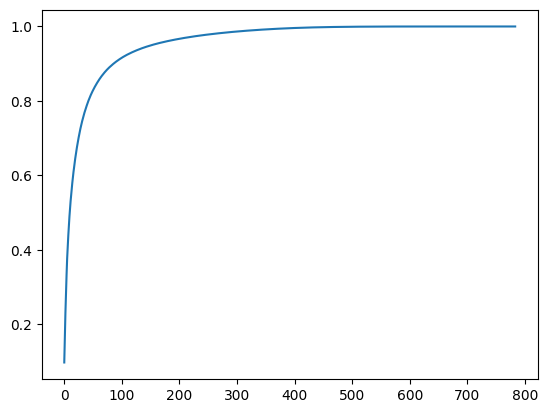

In [31]:
plt.plot(np.cumsum(pca.explained_variance_ratio_))